## Import data


In [663]:
# Common Python packages that will be used throughout project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [664]:
# List of column names. A header needs to be added because the raw data does not contain one.
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
# Create DataFrame from the dataset.
df = pd.read_csv('./data/car.data', header=None, names=col_names)
print(df)

     buying  maint  doors persons lug_boot safety  class
0     vhigh  vhigh      2       2    small    low  unacc
1     vhigh  vhigh      2       2    small    med  unacc
2     vhigh  vhigh      2       2    small   high  unacc
3     vhigh  vhigh      2       2      med    low  unacc
4     vhigh  vhigh      2       2      med    med  unacc
...     ...    ...    ...     ...      ...    ...    ...
1723    low    low  5more    more      med    med   good
1724    low    low  5more    more      med   high  vgood
1725    low    low  5more    more      big    low  unacc
1726    low    low  5more    more      big    med   good
1727    low    low  5more    more      big   high  vgood

[1728 rows x 7 columns]


In [665]:
feature_names = list(df.columns.values[:-1])
for feature in feature_names:
    unique_count = df[feature].nunique()
    unique_vals = df[feature].unique()
    print("{}: {} values, {}".format(feature, unique_count, unique_vals))

buying: 4 values, ['vhigh' 'high' 'med' 'low']
maint: 4 values, ['vhigh' 'high' 'med' 'low']
doors: 4 values, ['2' '3' '4' '5more']
persons: 3 values, ['2' '4' 'more']
lug_boot: 3 values, ['small' 'med' 'big']
safety: 3 values, ['low' 'med' 'high']


In [666]:
# Get a count of the number of unique values for the label column.
label_name = df.columns.values[-1]
print("{}: {} values, {}".format(label_name, df[label_name].nunique(), df[label_name].unique()))

class: 4 values, ['unacc' 'acc' 'vgood' 'good']


In [667]:
# Display total counts for each of the unique values in the label column.
df[label_name].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [668]:
# Create dummy columns for the categorical features. The drop_first parameter takes care of the k-1 explained above.
df_encoded = pd.get_dummies(df, columns=feature_names, drop_first=True)
df_encoded.tail()

,class,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med
1723,good,True,False,False,True,False,False,False,False,True,False,True,True,False,False,True
1724,vgood,True,False,False,True,False,False,False,False,True,False,True,True,False,False,False
1725,unacc,True,False,False,True,False,False,False,False,True,False,True,False,False,True,False
1726,good,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True
1727,vgood,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False


In [669]:
# Encode the class column. The class column contains the labels.
# class_uniques will be used later to map the predicted classes back into the original labels for easier interpretation. 
df_encoded['class'], class_uniques = pd.factorize(df_encoded['class'])
df_encoded.tail()

,class,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med
1723,3,True,False,False,True,False,False,False,False,True,False,True,True,False,False,True
1724,2,True,False,False,True,False,False,False,False,True,False,True,True,False,False,False
1725,0,True,False,False,True,False,False,False,False,True,False,True,False,False,True,False
1726,3,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True
1727,2,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False


In [670]:
import tkinter as tk
from tkinter import ttk, scrolledtext,messagebox
from sklearn.model_selection import train_test_split


def xem_du_lieu():
    # Tạo cửa sổ
    window = tk.Tk()
    window.title("Ứng dụng Machine Learning")
    window.geometry("1000x600")

    # Tạo một đối tượng Label để hiển thị kết quả
    result_label = tk.Label(window, text="", font=("Helvetica", 12))
    result_label.pack(pady=10)

    # Tạo một Treeview để hiển thị dữ liệu dưới dạng bảng
    tree = ttk.Treeview(window, columns=['STT'] + feature_names, show="headings", height=10)
    tree.heading('STT', text='STT')
    for feature in feature_names:
        tree.heading(feature, text=feature)
    tree['show'] = 'headings'
    tree.pack(pady=10)

    # Hiển thị dữ liệu trong bảng
    for index, row in enumerate(df.itertuples(), start=1):
        tree.insert("", index, values=[index] + list(row)[1:], tags=('centered',))

    result_label.config(text=f"Dữ liệu Car Evaluation")

    Len_data = len(df_encoded)

    # Thêm một widget Text để hiển thị thông tin chi tiết

    info_text = scrolledtext.ScrolledText(window, width=Len_data, height=15, wrap=tk.WORD)
    info_text.insert(tk.END, f"Thông tin chi tiết:\n\n")
    info_text.insert(tk.END, "Dữ liệu sau khi mã hóa:\n")
    info_text.insert(tk.END, df_encoded.to_string(index=False))

    info_text.pack(pady=10)

    # Khởi chạy vòng lặp chính của ứng dụng
    window.mainloop()


## Creating the model

In [671]:
# Features.
X = df_encoded.loc[:, 'buying_low':'safety_med']
# Labels.
y = df_encoded.loc[:, 'class']

In [672]:
from sklearn.model_selection import train_test_split

# Split the data into a training and test set with a 75%:25% split.
# The setting of the random state parameter allows for reproducability (i.e the split will always yield the same results).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [673]:
from sklearn.ensemble import RandomForestClassifier

# Create the random forest classifier using 100 decision trees.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the classifier. This is where the forest of decision trees are created.
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [674]:
# Predict the test set results.
y_pred = clf.predict(X_test)
# Show first five predictions.
y_pred[0:5]

array([0, 3, 0, 1, 0], dtype=int64)

In [675]:
# Predicted probabilities of the first five predictions.
clf.predict_proba(X_test)[0:5]

array([[0.94, 0.06, 0.  , 0.  ],
       [0.39, 0.02, 0.01, 0.58],
       [0.89, 0.11, 0.  , 0.  ],
       [0.1 , 0.54, 0.12, 0.24],
       [0.97, 0.  , 0.  , 0.03]])

In [676]:
from sklearn.metrics import accuracy_score

# Get the accuracy classification score.
accuracy_score(y_test, y_pred)

0.8865740740740741

In [677]:
from sklearn.metrics import confusion_matrix

# Restore the class labels from encoded values back to their original strings.
y_pred = class_uniques[y_pred]
y_test = class_uniques[y_test]
# Create the confusion matrix. Setting the labels parameter sets the order of the columns and rows in the matrix.
# First row/column shows unacceptable, second row/column shows acceptable etc.
confusion_matrix(y_test, y_pred, labels=['unacc', 'acc', 'good', 'vgood'])

array([[291,   3,   0,   0],
       [ 17,  79,   6,   1],
       [  0,   9,   6,   0],
       [  0,  10,   3,   7]], dtype=int64)

In [678]:
from sklearn.metrics import classification_report, accuracy_score
import tkinter as tk
from tkinter import ttk, scrolledtext


# Display the precision, recall, and F1 score for each class.
t = classification_report(y_test, y_pred, labels=['unacc', 'acc', 'good', 'vgood'])

def xem_bieu_do():
    # Create a Tkinter window
    window = tk.Tk()
    window.title("Ứng dụng Machine Learning")
    window.geometry("1000x600")

    # Create a Label to display the model evaluation
    result_label = tk.Label(window, text=f"Model Evaluation: Accuracy {accuracy_score(y_test, y_pred):.2%}", font=("Helvetica", 12))
    result_label.pack(pady=10)

    # Create a ScrolledText widget to display the classification report
    report_text = scrolledtext.ScrolledText(window, wrap=tk.WORD, width=60, height=20)
    report_text.insert(tk.END, t)
    report_text.pack(padx=10, pady=10)

    # Run the Tkinter main loop
    window.mainloop()


## Add Data

In [679]:
df_ordinal = df.copy()
df_ordinal.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [680]:
# Create the new encoded columns in the DataFrame by mapping the feature and label columns with the desired order.
df_ordinal['buying_ordinal'] = df_ordinal['buying'].map({'low':0, 'med':1, 'high':2, 'vhigh':3})
df_ordinal['maint_ordinal'] = df_ordinal['maint'].map({'low':0, 'med':1, 'high':2, 'vhigh':3})
df_ordinal['doors_ordinal'] = df_ordinal['doors'].map({'2':0, '3':1, '4':2, '5more':3})
df_ordinal['persons_ordinal'] = df_ordinal['persons'].map({'2':0, '4':1, 'more':2})
df_ordinal['lug_boot_ordinal'] = df_ordinal['lug_boot'].map({'small':0, 'med':1, 'big':2})
df_ordinal['safety_ordinal'] = df_ordinal['safety'].map({'low':0, 'med':1, 'high':2})
df_ordinal['class_ordinal'] = df_ordinal['class'].map({'unacc':0, 'acc':1, 'good':2, 'vgood':3})
# Remove the original columns.
df_ordinal.drop(columns=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], inplace=True)
# View last five rows of DataFrame.
df_ordinal.tail()

,buying_ordinal,maint_ordinal,doors_ordinal,persons_ordinal,lug_boot_ordinal,safety_ordinal,class_ordinal
1723,0,0,3,2,1,1,2
1724,0,0,3,2,1,2,3
1725,0,0,3,2,2,0,0
1726,0,0,3,2,2,1,2
1727,0,0,3,2,2,2,3


In [681]:
# Features.
X_ord = df_ordinal.iloc[:, :-1]
# Labels.
y_ord = df_ordinal.iloc[:, -1]
# Split the data for training and testing the classifier model.
X_ordtrain, X_ordtest, y_ordtrain, y_ordtest = train_test_split(X_ord, y_ord, test_size=0.25, random_state=42)
# Create the classifier.
clf_ord = RandomForestClassifier(n_estimators=100, random_state=42)
clf_ord.fit(X_ordtrain, y_ordtrain)
y_ordpred = clf_ord.predict(X_ordtest)

In [682]:
accuracy_score(y_ordtest, y_ordpred)

0.9629629629629629

In [683]:
# The labels were specified in the mapping earlier (unacc=0, acc=1, good=2, vgood=3).
confusion_matrix(y_ordtest, y_ordpred, labels=[0, 1, 2, 3])

array([[294,   0,   0,   0],
       [  3,  91,   8,   1],
       [  0,   0,  14,   1],
       [  0,   1,   2,  17]], dtype=int64)

In [684]:
# Display the precision, recall and F1 score for each class.
print(classification_report(y_ordtest, y_ordpred, labels=[0, 1, 2, 3]))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       294
           1       0.99      0.88      0.93       103
           2       0.58      0.93      0.72        15
           3       0.89      0.85      0.87        20

    accuracy                           0.96       432
   macro avg       0.86      0.92      0.88       432
weighted avg       0.97      0.96      0.96       432



In [685]:
h = classification_report(y_ordtest, y_ordpred, labels=[0, 1, 2, 3])
def du_doan_mo_hinh():
     # Create a Tkinter window
    window = tk.Tk()
    window.title("Ứng dụng Machine Learning")
    window.geometry("1000x600")

     # evaluate data from ... to
    # Create a Label to display the model evaluation
    result_label = tk.Label(window, text=f"Evaluate data from: Accuracy {accuracy_score(y_test, y_pred):.2%} to {accuracy_score(y_ordtest, y_ordpred):.2%}", font=("Helvetica", 12))
    result_label.pack(pady=10)

    # Create a ScrolledText widget to display the classification report
    report_text = scrolledtext.ScrolledText(window, wrap=tk.WORD, width=60, height=20)
    report_text.insert(tk.END, h)
    report_text.pack(padx=10, pady=10)

    # Run the Tkinter main loop
    window.mainloop()

## Feature selection

In [686]:
# Get the column names of the ordinal DataFrame from part two (apart from last which is the label column).
feat_names = list(df_ordinal.columns.values)[:-1]
# Get the feature importances from the RandomForestClassifier attribute.
feat_importances = clf_ord.feature_importances_
# Display the importances for each feature.
for name, imp in zip(feat_names, feat_importances):
    print("{}: {}".format(name, imp))

buying_ordinal: 0.15679496973015414
maint_ordinal: 0.15363336272819894
doors_ordinal: 0.06504475841161442
persons_ordinal: 0.23122593193956503
lug_boot_ordinal: 0.08972317931508356
safety_ordinal: 0.30357779787538386


C:\Users\hoang\AppData\Local\Temp\ipykernel_2564\2775281545.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  feat_imp_plot.set_xticklabels(feat_imp_plot.get_xticklabels(), rotation=90)


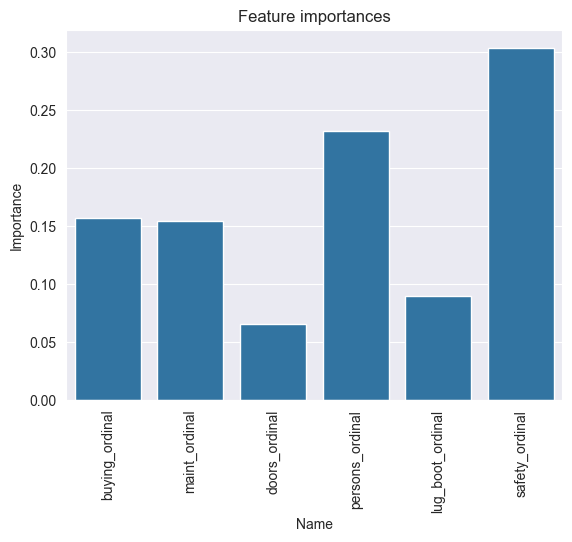

In [687]:
# Create bar plot of feature importance.
feat_imp_plot = sns.barplot(y=feat_importances, x=feat_names)
sns.set_style('darkgrid')
# Annotate plot.
plt.title("Feature importances")
plt.xlabel('Name')
plt.ylabel('Importance')
# Orientate the x-axis labels.
feat_imp_plot.set_xticklabels(feat_imp_plot.get_xticklabels(), rotation=90)
plt.show()

In [688]:
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
def du_doan_mo_hinh():
    fig, ax = plt.subplots(figsize=(6,4))  # Adjust the figure size here (width x height)
    feat_imp_plot = sns.barplot(y=feat_importances, x=feat_names, ax=ax)
    sns.set_style('darkgrid')

    # Annotate plot.
    ax.set_title("Feature importances")
    ax.set_xlabel('Name')
    ax.set_ylabel('Importance')

    # Orientate the x-axis labels.
    feat_imp_plot.set_xticklabels(feat_imp_plot.get_xticklabels(), rotation=90)

    # Create Tkinter window
    window = tk.Tk()
    window.title("Feature Importance Plot")
    window.geometry("1000x600")  # Set the desired size

    # Embed the plot into Tkinter window
    canvas = FigureCanvasTkAgg(fig, master=window)
    canvas_widget = canvas.get_tk_widget()
    canvas_widget.pack()

    # Run the Tkinter main loop
    window.mainloop()

## Creating and evaluting the model

In [689]:
from sklearn.feature_selection import SelectFromModel

# Sort the threshold importances.
feat_importances.sort()
# List to store number of selected features in each model.
num_selected_features = []
# List to store the accuracy of each model.
acc_scores = []
# Create, train and evaluate the accuracy of a classifier for selected features included at each threshold value.
for importance in feat_importances:
    print("\nThreshold importance value: {}".format(importance))

    # Create a meta-transformer for selecting features equal to or above a threshold importance value.
    sfm = SelectFromModel(clf_ord, threshold=importance)
    # Fit the meta-transformer on the training data.
    sfm.fit(X_ordtrain, y_ordtrain)

    # Get an array of indices of the selected features.
    imp_feature_indices = sfm.get_support(indices=True)
    
    # Get a count of the number of selected features at this threshold value.
    selected_features_count = len(imp_feature_indices)
    # Append count to list of numbers of selected features.
    num_selected_features.append(selected_features_count)
    # Display the number of selected features.
    print("{} selected features:".format(selected_features_count))
    
    # Use the indices array to print the selected features' index in the DataFrame, name and importance value.
    for imp_feature_index in imp_feature_indices:
        imp_feature_name = df_ordinal.columns[imp_feature_index]
        imp_feature_value = sfm.estimator_.feature_importances_[imp_feature_index]
        print("Df index: {}, Feature name: {}, Importance val: {}".format(imp_feature_index, imp_feature_name, imp_feature_value))

    # Reduce the features 'X' to just the selected features.
    X_fstrain = sfm.transform(X_ordtrain)
    X_fstest = sfm.transform(X_ordtest)

    # Create the classifier and make predictions.
    clf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_fs.fit(X_fstrain, y_ordtrain)
    y_fspred = clf_fs.predict(X_fstest)

    # Calculate the accuracy of the classifier.
    acc = accuracy_score(y_ordtest, y_fspred)
    # Append accuracy score to list of accuracy scores.
    acc_scores.append(acc)
    # Display the accuracy.
    print("Accuracy: {}".format(acc))

    # Display a confusion matrix. The labels were specified in the mapping earlier (unacc=0, acc=1, good=2, vgood=3).
    print(confusion_matrix(y_ordtest, y_fspred, labels=[0, 1, 2, 3]))


Threshold importance value: 0.06504475841161442
6 selected features:
Df index: 0, Feature name: buying_ordinal, Importance val: 0.15679496973015414
Df index: 1, Feature name: maint_ordinal, Importance val: 0.15363336272819894
Df index: 2, Feature name: doors_ordinal, Importance val: 0.06504475841161442
Df index: 3, Feature name: persons_ordinal, Importance val: 0.23122593193956503
Df index: 4, Feature name: lug_boot_ordinal, Importance val: 0.08972317931508356
Df index: 5, Feature name: safety_ordinal, Importance val: 0.30357779787538386
Accuracy: 0.9629629629629629
[[294   0   0   0]
 [  3  91   8   1]
 [  0   0  14   1]
 [  0   1   2  17]]

Threshold importance value: 0.08972317931508356
5 selected features:
Df index: 0, Feature name: buying_ordinal, Importance val: 0.15679496973015414
Df index: 1, Feature name: maint_ordinal, Importance val: 0.15363336272819894
Df index: 3, Feature name: persons_ordinal, Importance val: 0.23122593193956503
Df index: 4, Feature name: lug_boot_ordina

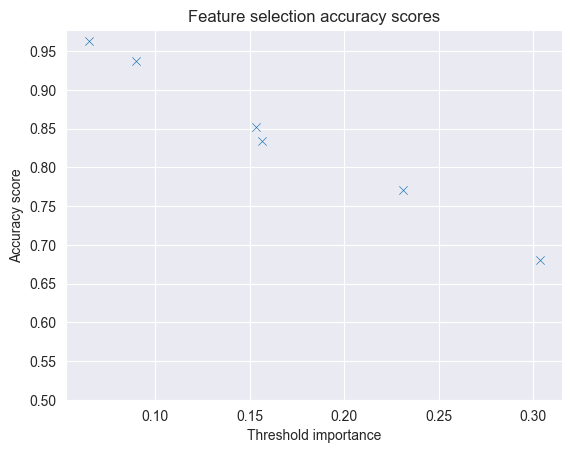

In [690]:
# Plot scatterplot with the accuracies at each threshold value.
sns.scatterplot(x=feat_importances, y=acc_scores, marker='x')
sns.set_style('darkgrid')
plt.yticks(np.arange(0.5, 1, 0.05))
plt.title("Feature selection accuracy scores")
plt.xlabel("Threshold importance")
plt.ylabel("Accuracy score")
plt.show()

In [691]:
# Create a new DataFrame where each row represents one of the feature selection models. 
df_fs_results = pd.DataFrame({"threshold_importance" : feat_importances, "no_selected_features" : num_selected_features, "accuracy" : acc_scores})
df_fs_results

,threshold_importance,no_selected_features,accuracy
0,0.065045,6,0.962963
1,0.089723,5,0.937500
2,0.153633,4,0.851852
3,0.156795,3,0.833333
4,0.231226,2,0.770833
5,0.303578,1,0.680556


Percentage change is calculated using the formula:

$$percentage\;change = \frac{new\;value - original\;value}{original\;value} \times 100$$

In [692]:
# Create a percentage change column in the DataFrame which shows the accuracy change of each feature selection model from the original.
df_fs_results["acc_pct_change"] = df_fs_results["accuracy"].apply(lambda x: ((x - df_fs_results["accuracy"].iloc[0])/df_fs_results["accuracy"].iloc[0]) * 100)
df_fs_results

,threshold_importance,no_selected_features,accuracy,acc_pct_change
0,0.065045,6,0.962963,0.000000
1,0.089723,5,0.937500,-2.644231
2,0.153633,4,0.851852,-11.538462
3,0.156795,3,0.833333,-13.461538
4,0.231226,2,0.770833,-19.951923
5,0.303578,1,0.680556,-29.326923


In [693]:
def tao_mo_hinh():
    # Sample data for demonstration
    feat_importances = np.random.rand(10)
    acc_scores = np.random.uniform(0.5, 1, 10)
    num_selected_features = np.random.randint(5, 15, 10)

    # Plot scatterplot with the accuracies at each threshold value.
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter_plot = sns.scatterplot(x=feat_importances, y=acc_scores, marker='x', ax=ax)
    sns.set_style('darkgrid')
    plt.yticks(np.arange(0.5, 1, 0.05))
    plt.title("Feature selection accuracy scores")
    plt.xlabel("Threshold importance")
    plt.ylabel("Accuracy score")

    # Create Tkinter window
    window = tk.Tk()
    window.title("Feature Selection Results")
    window.geometry("800x600")

    # Embed the scatterplot into Tkinter window
    canvas = FigureCanvasTkAgg(fig, master=window)
    canvas_widget = canvas.get_tk_widget()
    canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)

    # Create a new DataFrame where each row represents one of the feature selection models.
    df_fs_results = pd.DataFrame({"threshold_importance": feat_importances, "no_selected_features": num_selected_features, "accuracy": acc_scores})

    # Create a Treeview widget for displaying the DataFrame
    tree = ttk.Treeview(window)
    tree["columns"] = tuple(df_fs_results.columns)
    tree["show"] = "headings"

    # Set the column headings
    for column in df_fs_results.columns:
        tree.heading(column, text=column)

    # Insert data into the Treeview
    for index, row in df_fs_results.iterrows():
        tree.insert("", "end", values=list(row))

    # Pack the Treeview widget
    tree.pack(side=tk.TOP, padx=10, pady=10)

    # Run the Tkinter main loop
    window.mainloop()

## Main Apps

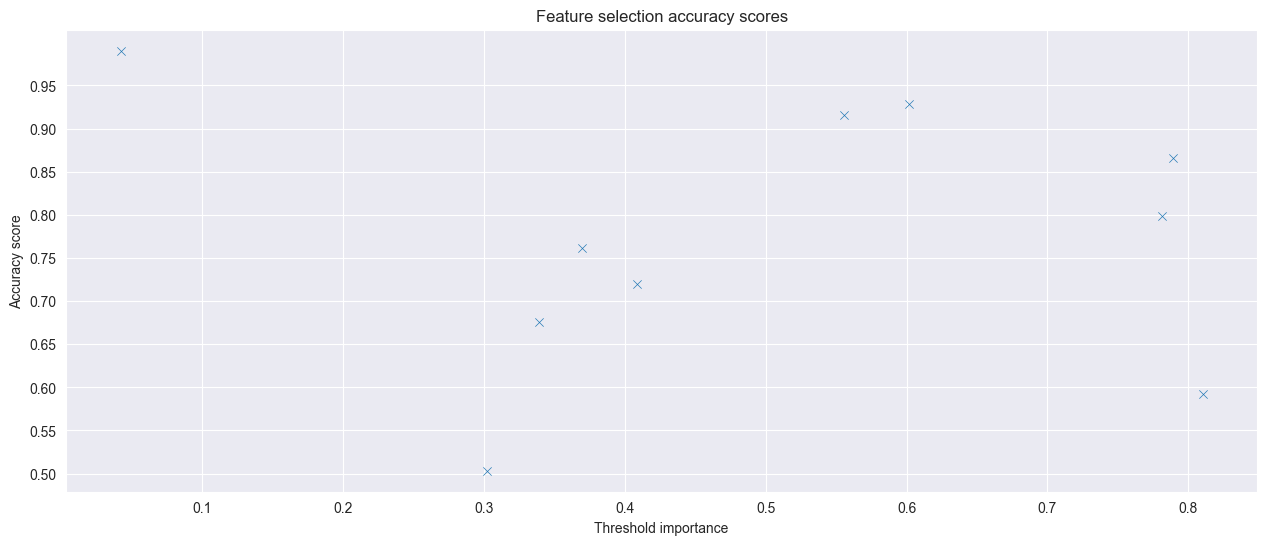

In [694]:
# Tạo cửa sổ
window = tk.Tk()
window.title("Ứng dụng")
window.geometry("500x350")
window.resizable(width=False, height=False)

# Thiết lập màu nền cho cửa sổ
window.configure(bg="lightgray")

# Tạo khung chứa nút bấm
frame = tk.Frame(window, bg="lightgray")
frame.place(relx=0.5, rely=0.5, anchor="center")

# Tạo nút bấm với kích thước và màu nền
btn_xem_bieu_do = tk.Button(frame, text="Xem biểu đồ", command=xem_bieu_do, width=20, height=2)
btn_xem_du_lieu = tk.Button(frame, text="Xem dữ liệu", command=xem_du_lieu, width=20, height=2)
btn_du_doan_mo_hinh = tk.Button(frame, text="Dự đoán mô hình", command=du_doan_mo_hinh, width=20, height=2)
btn_tao_mo_hinh = tk.Button(frame, text="Tạo mô hình", command=tao_mo_hinh, width=20, height=2)

# Đặt nút bấm trong khung
btn_xem_du_lieu.grid(row=0,pady=10)
btn_xem_bieu_do.grid(row=1, pady=10)
btn_du_doan_mo_hinh.grid(row=2, pady=10)
btn_tao_mo_hinh.grid(row=3, pady=10)

# Khởi chạy vòng lặp chính của ứng dụng
window.mainloop()
